Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

In [6]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
merged = pd.merge(
    cardiac_hgf_df[cardiac_hgf_df.session == 1],
    cardiac_hgf_df[cardiac_hgf_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

In [3]:
# removing outliers
print(f"{merged.participant_id.nunique()} participant before outliers removal.")
merged = merged[
    ~(
        pg.madmedianrule(merged.logit_interoceptive_sensitivity_del1)
        | pg.madmedianrule(merged.logit_interoceptive_sensitivity_del2)
    )
]
print(
    f"{merged.participant_id.nunique()} participant after outliers removal (interoception)."
)
merged = merged[
    ~(
        pg.madmedianrule(merged.logit_exteroceptive_sensitivity_del1)
        | pg.madmedianrule(merged.logit_exteroceptive_sensitivity_del2)
    )
]
print(
    f"{merged.participant_id.nunique()} participant after outliers removal (exteroception)."
)

187 participant before outliers removal.
157 participant after outliers removal (interoception).
135 participant after outliers removal (exteroception).


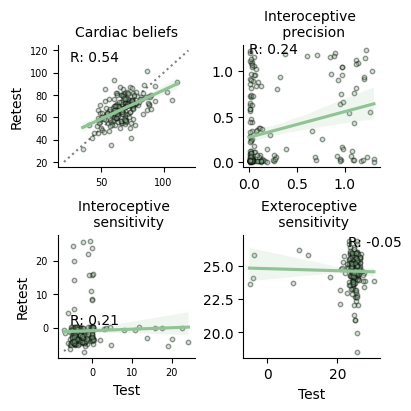

In [7]:
fig, axs = plt.subplots(figsize=(4, 4), nrows=2, ncols=2)

sns.regplot(
    x=merged["cardiac_belief_del1"],
    y=merged["cardiac_belief_del2"],
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    color="#92c396",
    ax=axs[0, 0],
)
axs[0, 0].annotate(
    f"R: {
        round(
            pg.corr(
                x=merged['cardiac_belief_del1'].to_numpy(),
                y=merged['cardiac_belief_del2'].to_numpy(),
                method='spearman',
            ).r.iloc[0],
            2,
        )
    }",
    (25, 110),
)

sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"],
    y=merged["logit_interoceptive_sensitivity_del2"],
    color="#92c396",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    ax=axs[1, 0],
)
axs[1, 0].annotate(
    f"R: {
        round(
            pg.corr(
                x=merged['logit_interoceptive_sensitivity_del1'].to_numpy(),
                y=merged['logit_interoceptive_sensitivity_del2'].to_numpy(),
                method='spearman',
            ).r.iloc[0],
            2,
        )
    }",
    (-5.5, 1),
)

sns.regplot(
    x=merged["interoceptive_precision_del1"],
    y=merged["interoceptive_precision_del2"],
    color="#92c396",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    ax=axs[0, 1],
)
axs[0, 1].annotate(
    f"R: {
        round(
            pg.corr(
                x=merged['interoceptive_precision_del1'].to_numpy(),
                y=merged['interoceptive_precision_del2'].to_numpy(),
                method='spearman',
            ).r.iloc[0],
            2,
        )
    }",
    (0, 1.2),
)

sns.regplot(
    x=merged["logit_exteroceptive_sensitivity_del1"],
    y=merged["logit_exteroceptive_sensitivity_del2"],
    color="#92c396",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    ax=axs[1, 1],
)
axs[1, 1].annotate(
    f"R: {
        round(
            pg.corr(
                x=merged['logit_exteroceptive_sensitivity_del1'].to_numpy(),
                y=merged['logit_exteroceptive_sensitivity_del2'].to_numpy(),
                method='spearman',
            ).r.iloc[0],
            2,
        )
    }",
    (23, 26.5),
)

axs[0, 0].plot((20, 120), (20, 120), linestyle=":", color="gray", zorder=0)
axs[0, 0].tick_params(axis="both", labelsize=7)
axs[1, 0].plot((-7, 2), (-7, 2), linestyle=":", color="gray", zorder=0)
axs[1, 0].tick_params(axis="both", labelsize=7)

axs[0, 0].set_title("Cardiac beliefs", fontsize=10)
axs[0, 1].set_title("Interoceptive \n precision", fontsize=10)
axs[1, 0].set_title("Interoceptive \n sensitivity", fontsize=10)
axs[1, 1].set_title("Exteroceptive \n sensitivity", fontsize=10)

axs[0, 0].set(xlabel=None, ylabel="Retest")
axs[1, 0].set(xlabel="Test", ylabel="Retest")
axs[0, 1].set(xlabel=None, ylabel=None)
axs[1, 1].set(xlabel="Test", ylabel=None)

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_4_reliability.svg")